In [7]:
import numpy as np #ignore
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

%matplotlib inline

def show_layout():
    plt.figure(figsize=(9, 4))
    plt.tight_layout()
    plt.show()

In [8]:
TRAIN_PATH = r"C:\Users\AYO_AYO\Desktop\Machine-Learning-Bootcamp\Data_Preprocessing\titanic_train_encoded.csv"
TEST_PATH = r"C:\Users\AYO_AYO\Desktop\Machine-Learning-Bootcamp\Data_Preprocessing\titanic_test_encoded.csv"

X_train_df = pd.read_csv(TRAIN_PATH)
X_test_df = pd.read_csv(TEST_PATH)

In [9]:
X_train_df.head()

,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_Q,embarked_S,who_man,who_woman,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,survived
0,3,1,28.5,0,0,56.4958,1,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
1,2,1,28.5,0,0,0.0000,1,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,1,1,28.5,0,0,221.7792,1,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
3,3,0,18.0,0,1,9.3500,0,0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1
4,2,0,31.0,1,1,26.2500,0,0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1


**Loading the encoded data**

In [10]:
target = "survived"

X_train = X_train_df.drop(columns=target)
y_train = X_train_df[target]

X_test = X_test_df.drop(columns=target)
y_test = X_test_df[target]

num_cols = X_train.select_dtypes([np.number]).values

In [11]:
print("X train shape", X_train.shape)
print("X test shape", X_test.shape)

X train shape (712, 18)
X test shape (179, 18)


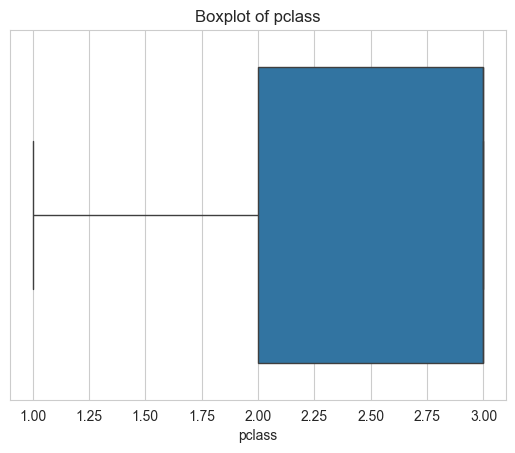

<Figure size 900x400 with 0 Axes>

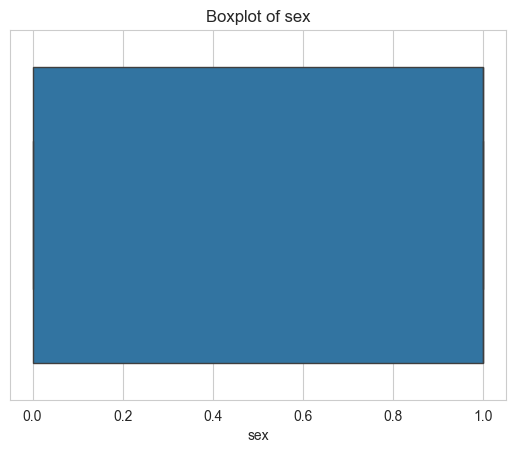

<Figure size 900x400 with 0 Axes>

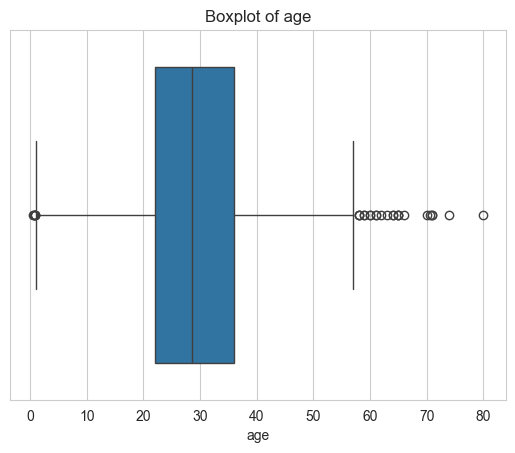

<Figure size 900x400 with 0 Axes>

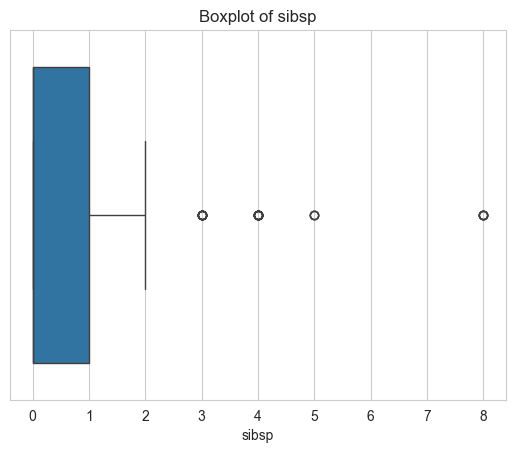

<Figure size 900x400 with 0 Axes>

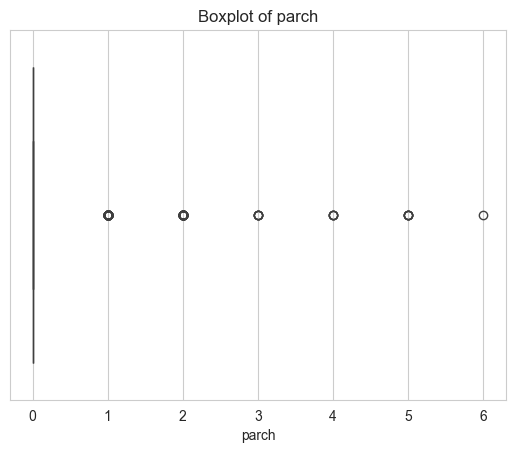

<Figure size 900x400 with 0 Axes>

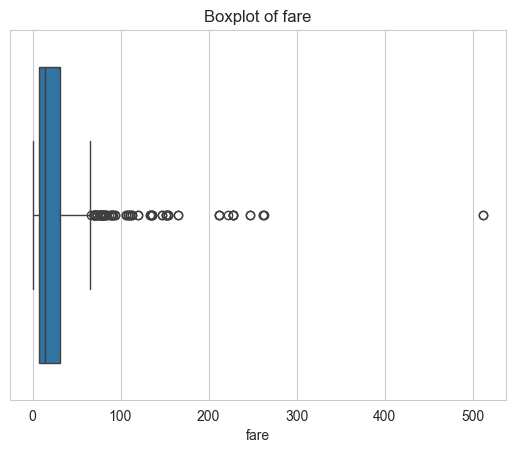

<Figure size 900x400 with 0 Axes>

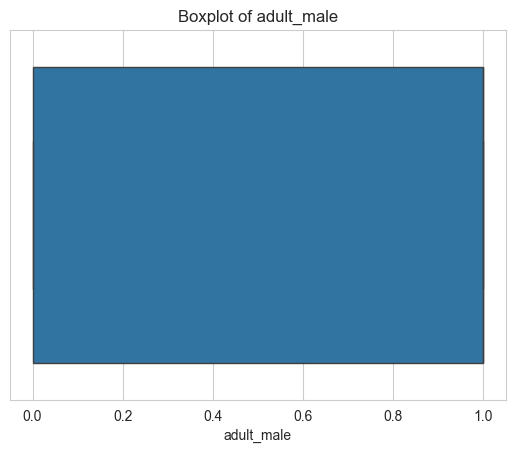

<Figure size 900x400 with 0 Axes>

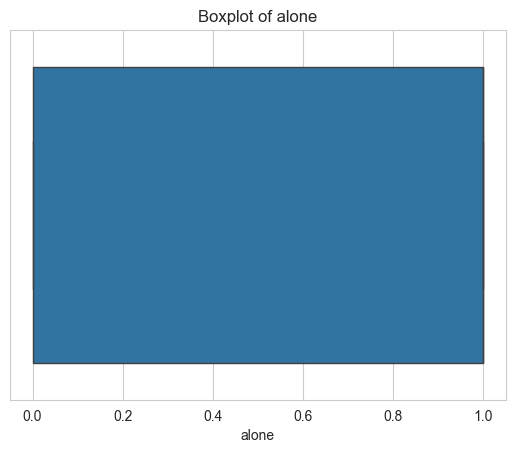

<Figure size 900x400 with 0 Axes>

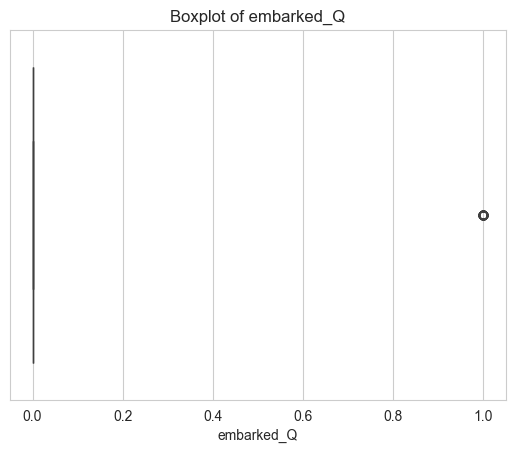

<Figure size 900x400 with 0 Axes>

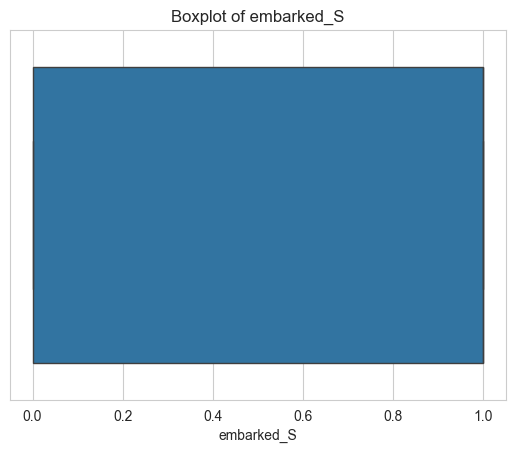

<Figure size 900x400 with 0 Axes>

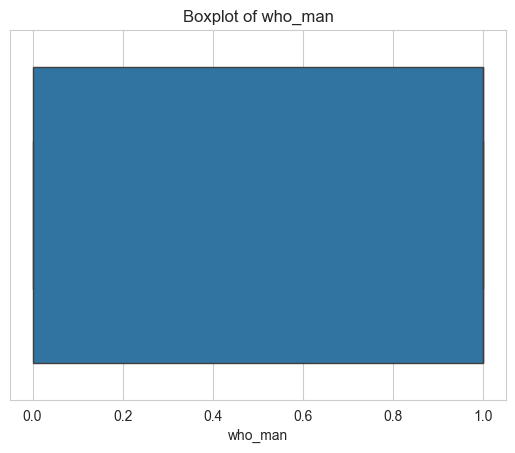

<Figure size 900x400 with 0 Axes>

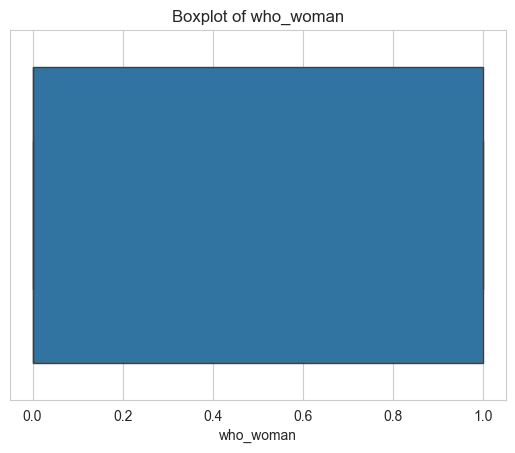

<Figure size 900x400 with 0 Axes>

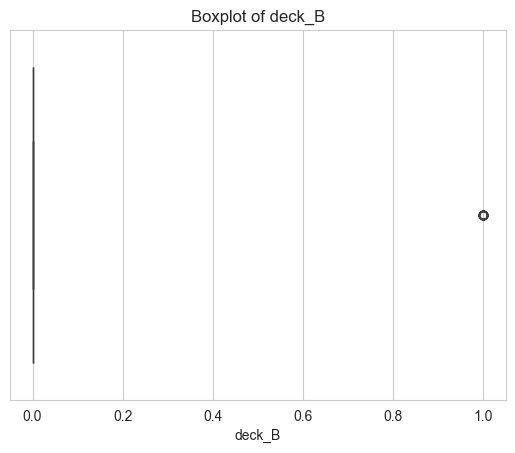

<Figure size 900x400 with 0 Axes>

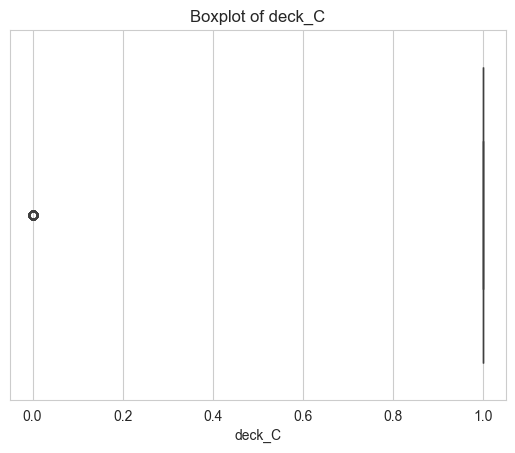

<Figure size 900x400 with 0 Axes>

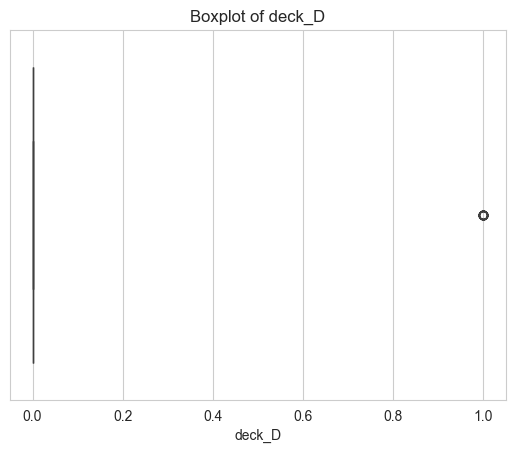

<Figure size 900x400 with 0 Axes>

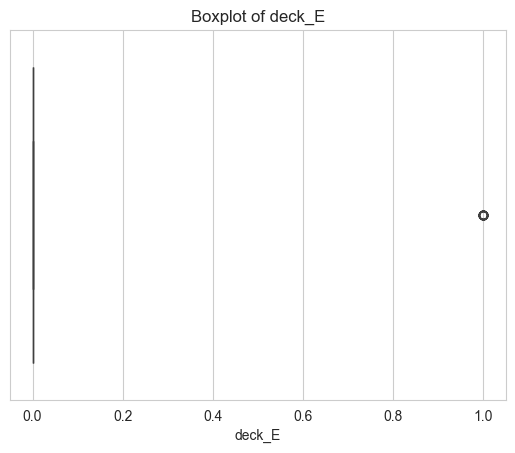

<Figure size 900x400 with 0 Axes>

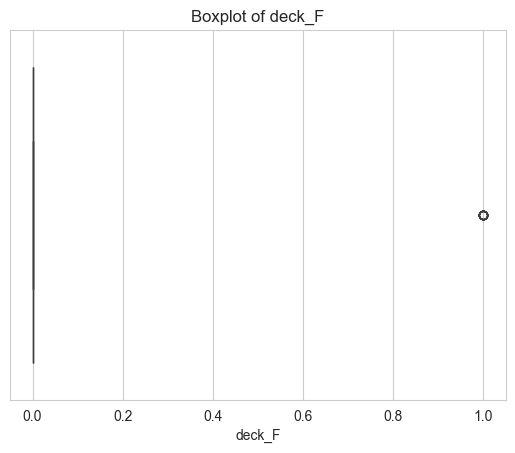

<Figure size 900x400 with 0 Axes>

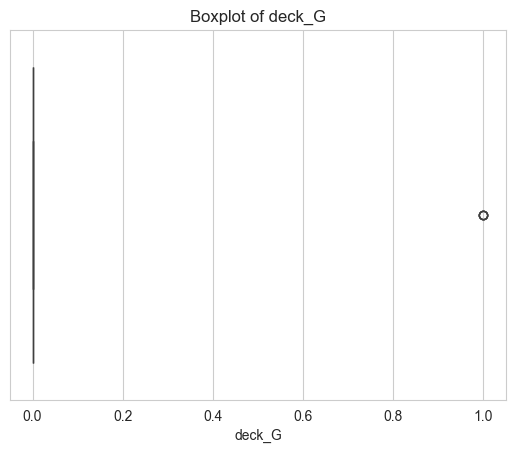

<Figure size 900x400 with 0 Axes>

In [12]:
num_cols = [col for col in X_train.columns if X_train[col].dtype in [
    "int64", "float64"]]

for cols in num_cols:
    sns.boxplot(x=X_train[cols])
    plt.title(f"Boxplot of {cols}")
    show_layout()

**IQR**

In [13]:
valid_outliers_cols = ["age", "fare"]

In [14]:
def iqr_bound(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

In [15]:
# compute bounds only on TRAIN set
def compute_train_bounds(df, cols):
    bounds = {}
    for col in cols:
        low, high = iqr_bound(df[col])
        bounds[col] = (low, high)
    return bounds

In [16]:
# apply the same bounds to any set (train/test)
def cap_outliers_with_bounds(df, bounds):
    df_capped = df.copy()
    for col, (low, high) in bounds.items:
        df_capped[col] = np.where(df_capped[col] < low, low, df_capped[col])
        df_capped[col] = np.where(df_capped[col] < high, high, df_capped[col])
    return df_capped

In [17]:
train_bounds = compute_train_bounds(X_train_df, valid_outliers_cols)